# Importing Libraries

In [1]:
import os
import time
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from xml.etree import ElementTree as ET
from sklearn import preprocessing
from tqdm.notebook import tqdm
import time

import seaborn as sns

import torch
from torch.utils.data import DataLoader, Dataset
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchmetrics.detection.mean_ap import MeanAveragePrecision

import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2


/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.7' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


# Paths & Param Initializing

In [2]:
BASE_PATH = "../input/pascal-voc-2012/VOC2012"
XML_PATH = os.path.join(BASE_PATH, "Annotations")
IMG_PATH = os.path.join(BASE_PATH, "JPEGImages")
XML_FILES = [os.path.join(XML_PATH, f) for f in os.listdir(XML_PATH) if f.endswith('.xml')]

NUM_CLASSES = 21  # 20 فئة + background
BATCH_SIZE = 4
NUM_EPOCHS = 1


# Loading Xml into Dataframe

In [3]:
class XmlParser:
    def __init__(self, xml_file):
        self.xml_file = xml_file
        self._root = ET.parse(xml_file).getroot()
        self.img_path = os.path.join(IMG_PATH, self._root.find("filename").text)
        self.image_id = self._root.find("filename").text
        self.names = self._get_names()
        self.boxes = self._get_bndboxes()

    def _get_names(self):
        return [obj.find("name").text for obj in self._root.findall("object")]

    def _get_bndboxes(self):
        boxes = []
        for obj in self._root.findall("object"):
            b = obj.find("bndbox")
            box = [int(float(b.find(tag).text)) for tag in ("xmin", "ymin", "xmax", "ymax")]
            boxes.append(box)
        return boxes

def xml_files_to_df(xml_files):
    records = []
    for file in tqdm(xml_files, desc="Parsing XML files"):
        xml = XmlParser(file)
        for name, box in zip(xml.names, xml.boxes):
            records.append({
                "img_path": xml.img_path,
                "img_id": xml.image_id.split('.')[0],
                "name": name,
                "box": box
            })
    return pd.DataFrame(records)

df = xml_files_to_df(XML_FILES)


Parsing XML files:   0%|          | 0/17125 [00:00<?, ?it/s]

# Data Processing

In [4]:
# encoding classes
enc = preprocessing.LabelEncoder()
df["label"] = enc.fit_transform(df["name"]) + 1

# extracting coordinates from boxes
df[["xmin", "ymin", "xmax", "ymax"]] = pd.DataFrame(df["box"].to_list(), index=df.index)
df = df.drop(columns=["name", "box"])

# data spiltting
image_ids = df["img_id"].unique()
valid_ids = image_ids[-4000:]
train_ids = image_ids[:-4000]

train_df = df[df["img_id"].isin(train_ids)].reset_index(drop=True)
valid_df = df[df["img_id"].isin(valid_ids)].reset_index(drop=True)

# dic of classes
classes = dict(zip(range(1, 21), enc.classes_))


## Data Visualization


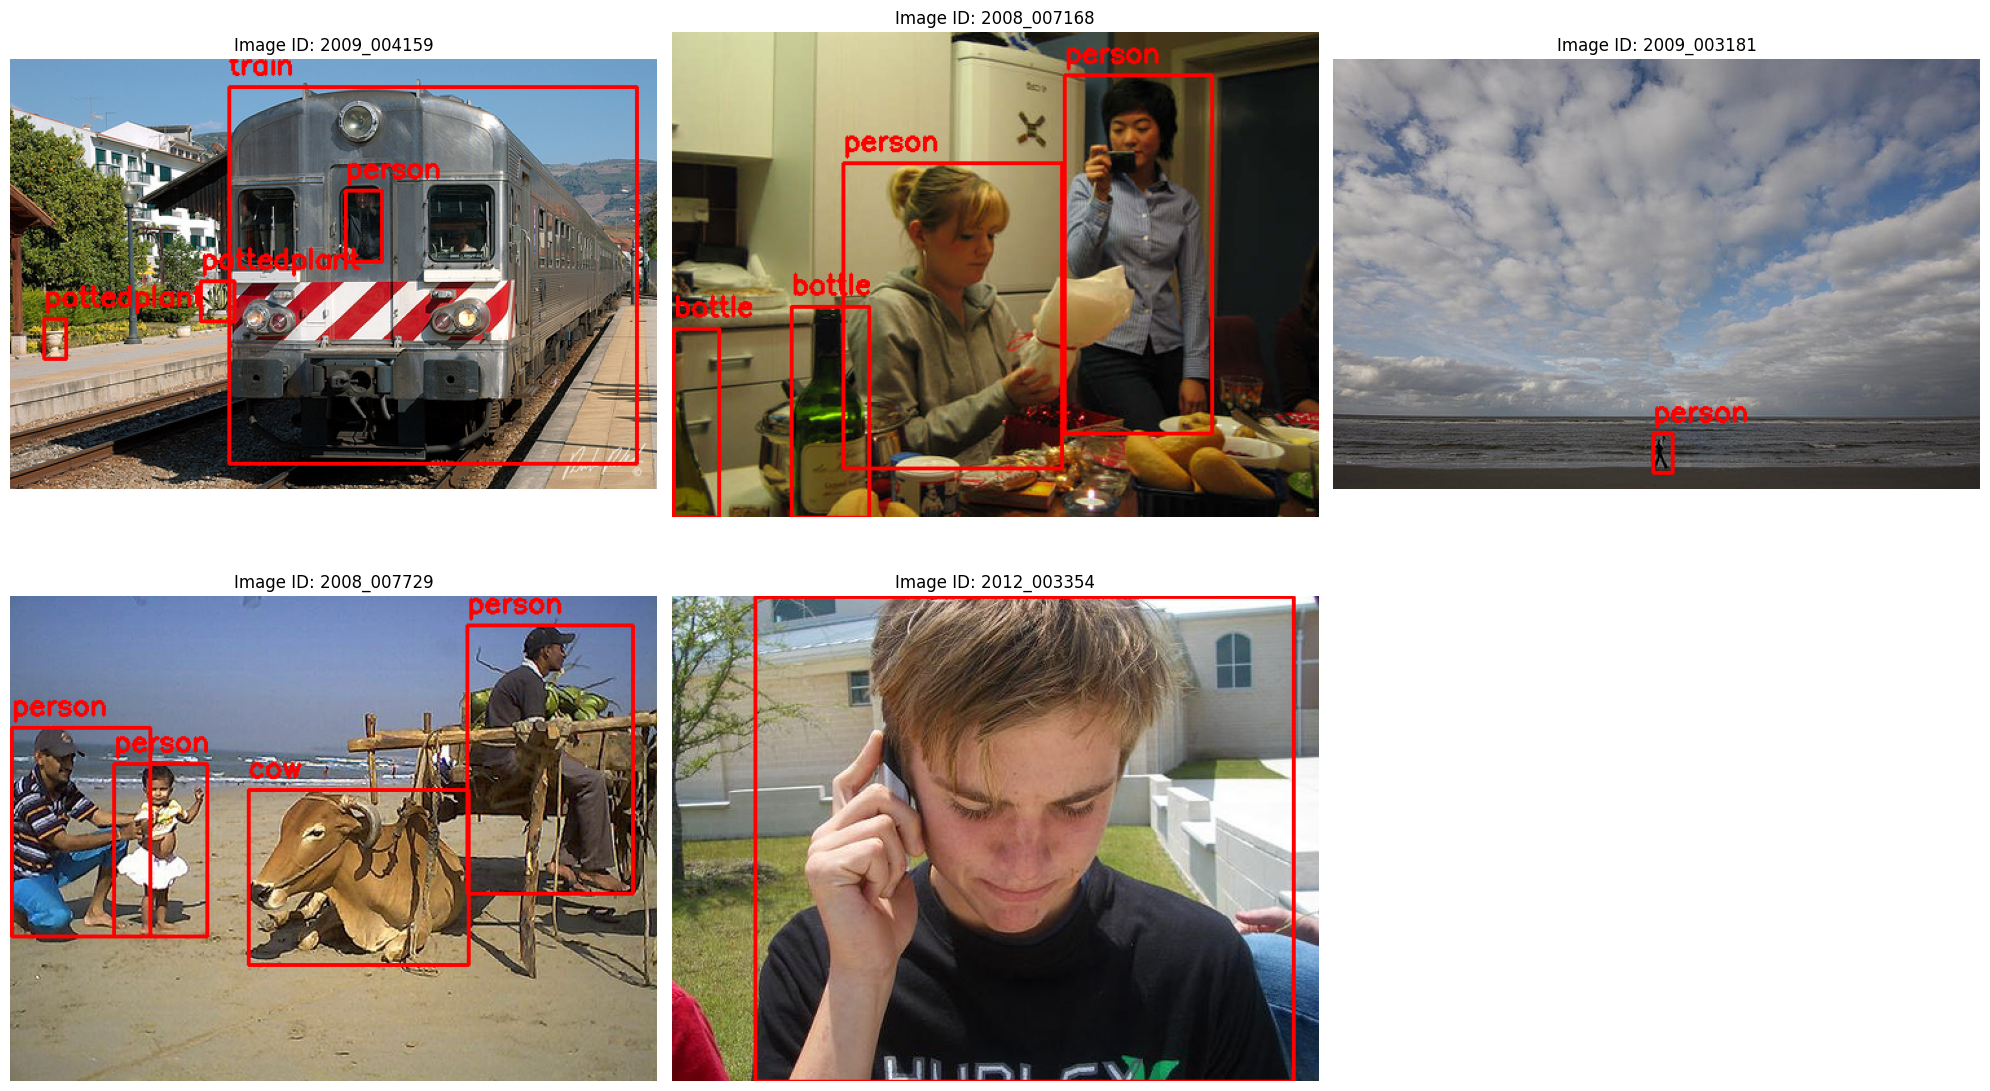

In [5]:
def plot_sample_images(df, num_samples=5, random_state=42):
    """Visualize sample images with bounding boxes and labels"""
    plt.figure(figsize=(20, 12))
    sample_df = df.sample(num_samples, random_state=random_state)
    
    for i, (_, row) in enumerate(sample_df.iterrows()):
        img = cv2.imread(row['img_path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Get all objects for this image
        img_objects = df[df['img_id'] == row['img_id']]
        
        plt.subplot(2, 3, i+1)
        for _, obj in img_objects.iterrows():
            # Draw bounding box
            cv2.rectangle(img, 
                         (obj['xmin'], obj['ymin']), 
                         (obj['xmax'], obj['ymax']), 
                         color=(255, 0, 0), thickness=2)
            
            # Put label text
            label = classes[obj['label']] if obj['label'] in classes else 'background'
            cv2.putText(img, label, 
                       (obj['xmin'], obj['ymin']-10), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
        
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Image ID: {row['img_id']}")
    
    plt.tight_layout()
    plt.show()

# Plot sample images with annotations
plot_sample_images(df)



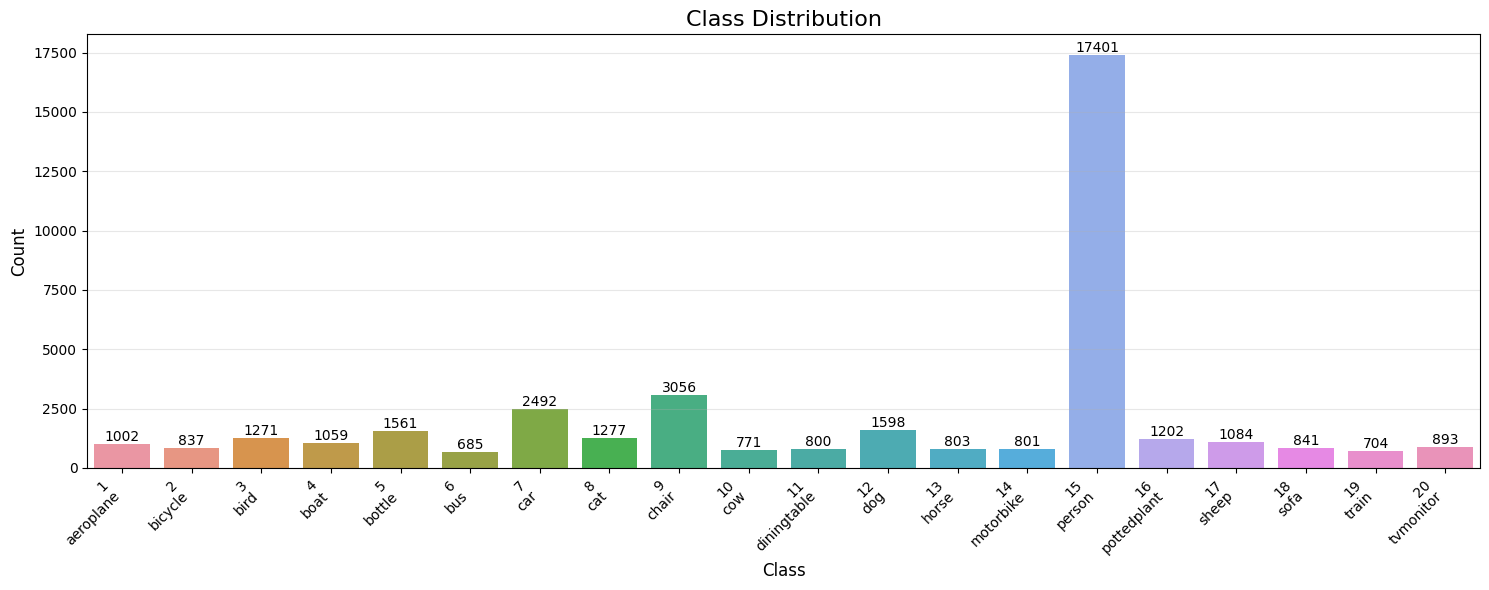

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


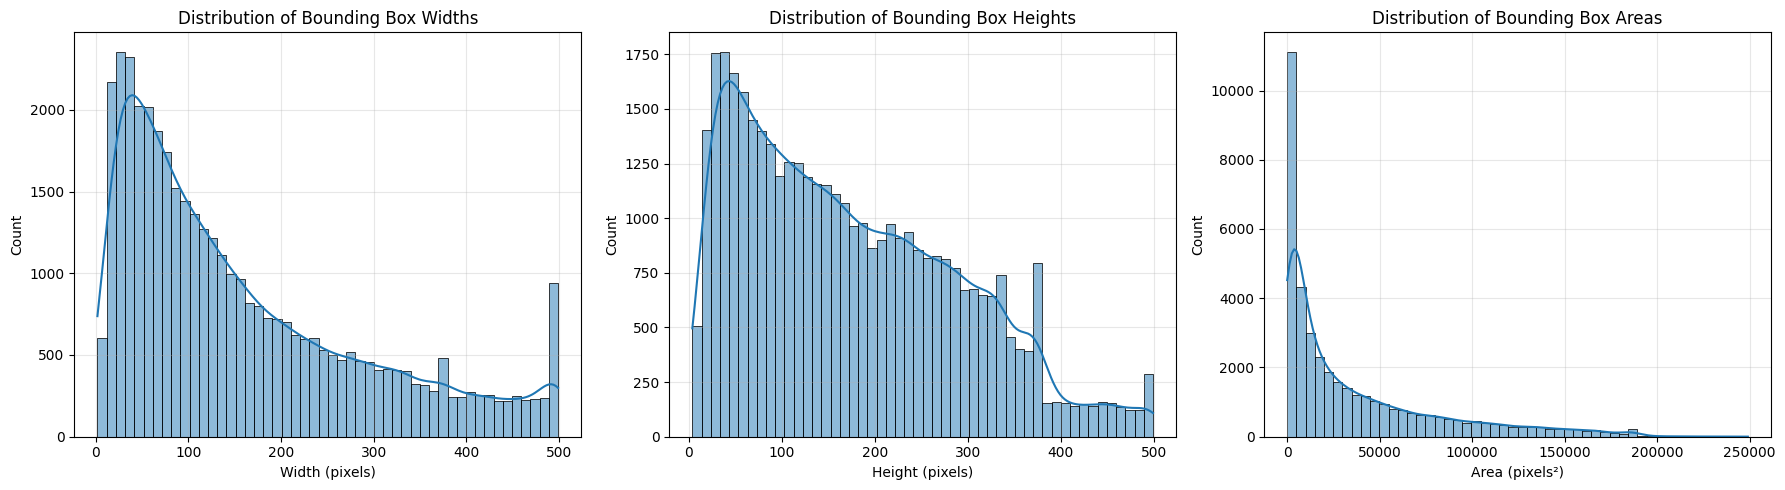

In [6]:
# %%
# Class distribution visualization - FIXED
plt.figure(figsize=(15, 6))
ax = sns.countplot(data=df, x='label', order=sorted(df['label'].unique()))
plt.title('Class Distribution', fontsize=16)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Get proper class labels
class_labels = [f"{class_id}\n{classes[class_id]}" for class_id in sorted(classes.keys())]

# Set x-axis labels
ax.set_xticks(range(len(class_labels)))
ax.set_xticklabels(class_labels, rotation=45, ha='right')

# Add count values on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# %%
# Bounding box statistics visualization
box_widths = df['xmax'] - df['xmin']
box_heights = df['ymax'] - df['ymin']
box_areas = box_widths * box_heights

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(box_widths, bins=50, kde=True)
plt.title('Distribution of Bounding Box Widths')
plt.xlabel('Width (pixels)')
plt.grid(alpha=0.3)

plt.subplot(1, 3, 2)
sns.histplot(box_heights, bins=50, kde=True)
plt.title('Distribution of Bounding Box Heights')
plt.xlabel('Height (pixels)')
plt.grid(alpha=0.3)

plt.subplot(1, 3, 3)
sns.histplot(box_areas, bins=50, kde=True)
plt.title('Distribution of Bounding Box Areas')
plt.xlabel('Area (pixels²)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Configuring Dataset & Transformars

In [7]:
class VOCDataset(Dataset):
    def __init__(self, dataframe, image_dir, transforms=None):
        self.image_ids = dataframe["img_id"].unique()
        self.df = dataframe
        self.image_dir = image_dir
        self.transforms = transforms

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        records = self.df[self.df["img_id"] == image_id]
        image = cv2.imread(os.path.join(self.image_dir, f"{image_id}.jpg"))
        image = (cv2.cvtColor(image, cv2.COLOR_BGR2RGB) / 255.0).astype(np.float32)
        # image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB).astype(np.uint8)
        boxes = records[["xmin", "ymin", "xmax", "ymax"]].values
        labels = records["label"].values
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        iscrowd = torch.zeros((records.shape[0],), dtype=torch.int64)

        target = {
            "boxes": torch.as_tensor(boxes, dtype=torch.float32),
            "labels": torch.as_tensor(labels, dtype=torch.int64),
            "area": torch.as_tensor(area, dtype=torch.float32),
            "iscrowd": iscrowd,
            "image_id": torch.tensor([idx])
        }

        if self.transforms:
            sample = self.transforms(image=image, bboxes=boxes, labels=labels)
            image = sample["image"]
            target["boxes"] = torch.tensor(sample["bboxes"], dtype=torch.float32)

        return image, target

    def __len__(self):
        return len(self.image_ids)

def get_transform(train=True):
    transforms = [A.HorizontalFlip(p=0.5)] if train else []
    transforms += [ToTensorV2()]
    return A.Compose(transforms, bbox_params=A.BboxParams(format="pascal_voc", label_fields=["labels"]))


# Loading into Dataloader

In [8]:
def collate_fn(batch):
    return tuple(zip(*batch))

train_dataset = VOCDataset(train_df, IMG_PATH, get_transform(train=True))
valid_dataset = VOCDataset(valid_df, IMG_PATH, get_transform(train=False))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, collate_fn=collate_fn)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, collate_fn=collate_fn)


/usr/local/lib/python3.11/dist-packages/albumentations/core/composition.py:250: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()


# Configuring Model

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = fasterrcnn_resnet50_fpn(pretrained=True)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)
model.to(device)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:00<00:00, 199MB/s]


# Training & Evaluating Model

In [ ]:
from tqdm import tqdm

train_losses = []
val_maps = []
val_map_50s = []

num_epochs = 3

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    start_time = time.time()

    train_bar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
    for i, (images, targets) in train_bar:
        images = [image.to(device) for image in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        epoch_loss += losses.item()

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        # Update progress bar
        train_bar.set_postfix(loss=losses.item(), avg_loss=epoch_loss / (i + 1),
                              lr=optimizer.param_groups[0]['lr'])

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    lr_scheduler.step()

    print(f"Epoch {epoch+1}: Train Loss = {avg_loss:.4f} | Time: {time.time()-start_time:.1f}s")

    # ============ Evaluation ============ #
    model.eval()
    map_metric = MeanAveragePrecision(iou_type="bbox")  # إعادة التعيين لكل Epoch

    preds, targets_list = [], []
    with torch.no_grad():
        val_bar = tqdm(valid_loader, total=len(valid_loader), desc=f"Epoch {epoch+1}/{num_epochs} [Val]")
        for images, targets in val_bar:
            images = [img.to(device) for img in images]
            outputs = model(images)

            for output, target in zip(outputs, targets):
                preds.append({
                    "boxes": output["boxes"].cpu(),
                    "scores": output["scores"].cpu(),
                    "labels": output["labels"].cpu()
                })
                targets_list.append({
                    "boxes": target["boxes"].cpu(),
                    "labels": target["labels"].cpu()
                })

    map_metric.update(preds, targets_list)
    val_results = map_metric.compute()

    val_maps.append(val_results["map"].item())
    val_map_50s.append(val_results["map_50"].item())

    print(f"\n==== Evaluation Epoch {epoch+1} ====")
    print(f"mAP: {val_results['map']:.4f}")
    print(f"mAP@0.5: {val_results['map_50']:.4f}")
    print(f"mAP@0.75: {val_results['map_75']:.4f}")
    print(f"mAP(Small): {val_results['map_small']:.4f}")
    print(f"mAP(Medium): {val_results['map_medium']:.4f}")
    print(f"mAP(Large): {val_results['map_large']:.4f}")
    print(f"Mean IoU: {val_results['map']:.4f}")
    print("="*40)

    map_metric.reset()
torch.save(model.state_dict(), 'faster_rcnn_state.pth')

Epoch 1/3 [Train]: 100%|██████████| 3282/3282 [36:53<00:00,  1.48it/s, avg_loss=0.333, loss=0.221, lr=0.005]


Epoch 1: Train Loss = 0.3332 | Time: 2213.6s


Epoch 1/3 [Val]: 100%|██████████| 1000/1000 [05:09<00:00,  3.23it/s]



==== Evaluation Epoch 1 ====
mAP: 0.4167
mAP@0.5: 0.6878
mAP@0.75: 0.4564
mAP(Small): 0.1746
mAP(Medium): 0.3352
mAP(Large): 0.4755
Mean IoU: 0.4167


Epoch 2/3 [Train]: 100%|██████████| 3282/3282 [36:55<00:00,  1.48it/s, avg_loss=0.247, loss=0.245, lr=0.005]


...


==== Evaluation Epoch 2 ====
mAP: 0.4448
mAP@0.5: 0.7044
mAP@0.75: 0.4971
mAP(Small): 0.1785
mAP(Medium): 0.3585
mAP(Large): 0.5070
Mean IoU: 0.4448


Epoch 3/3 [Train]: 100%|██████████| 3282/3282 [37:01<00:00,  1.48it/s, avg_loss=0.23, loss=0.0596, lr=0.005]


Epoch 3: Train Loss = 0.2301 | Time: 2221.7s


Epoch 3/3 [Val]: 100%|██████████| 1000/1000 [05:10<00:00,  3.22it/s]



==== Evaluation Epoch 3 ====
mAP: 0.4547
mAP@0.5: 0.7169
mAP@0.75: 0.5057
mAP(Small): 0.1726
mAP(Medium): 0.3558
mAP(Large): 0.5212
Mean IoU: 0.4547


### Save the model in a CPU-compatible way

In [11]:
# Save the model in a CPU-compatible way
save_path = 'faster_rcnn_cpu.pth'

# 1. Move model to CPU before saving
model.to('cpu')

# 2. Save both model state and important metadata
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': num_epochs,
    'classes': classes,  # Save your class mapping
    'label_encoder': enc.classes_  # Save label encoder info
}, save_path)

print(f"Model saved to {save_path} (Size: {os.path.getsize(save_path)/1e6:.2f} MB)")

Model saved to faster_rcnn_cpu.pth (Size: 166.12 MB)
